# Customer Segmentation Using K-Means Clustering

## Project Objective

The objective of this project is to segment customers into meaningful groups based on their demographic information, purchasing behavior, spending patterns, campaign responses, and digital activity.

This is an **unsupervised learning** problem because there is no predefined target variable. The customer groups will be discovered using the **K-Means clustering algorithm**.

### Workflow followed

1. Problem Understanding
2. Data Understanding
3. Data Cleaning
4. Remove Unnecessary Columns
5. Feature Selection
6. Encoding
7. Feature Scaling
8. Final Data Validation
9. PCA / Dimensionality Reduction
10. Final X for Clustering
11. K-Means Clustering
12. Cluster Evaluation
13. Cluster Profiling
14. Business Interpretation
15. Visualization
16. Conclusion

> **Note:** Only K-Means is implemented. Hierarchical Clustering and DBSCAN are intentionally not included.


## 1. Problem Understanding

Customer segmentation helps a business divide customers into groups with similar characteristics.

The main questions are:

- Can customers be grouped according to their purchasing behavior?
- Which groups have higher spending?
- Which groups are more active through web, catalog, or store purchases?
- Which groups show different campaign responses?
- What characteristics describe each discovered customer segment?

K-Means is suitable because it can discover groups without requiring predefined customer labels.


## 2. Import Required Libraries

The following libraries are used for data handling, preprocessing, clustering, dimensionality reduction, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.


### What is the use of this code?

- `pandas` is used to read and analyze the dataset.
- `numpy` is used for numerical operations.
- `matplotlib` is used to create graphs.
- `StandardScaler` is used to scale numerical features.
- `OneHotEncoder` is used to convert selected categorical features into numerical form.
- `KMeans` is the clustering algorithm used in this project.
- `PCA` is used to reduce dimensions for visualization.
- `silhouette_score` is used to evaluate the quality of the clusters.


## 3. Load the Dataset

The dataset is loaded from the given Windows file path.

In [2]:
file_path = r"C:\Users\hp\Desktop\Trivikram\phase 2\Module 4 Unsupervised Learning\customer segmentation dataset\customer_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


### What is the use of this code?

`pd.read_csv()` reads the CSV file and stores it as a DataFrame named `df`.

The `r` before the Windows path prevents backslashes from being interpreted as special characters.


## 4. First Look at the Dataset

In [3]:
df.head()

,Customer_ID,Birth_Year,Education_Level,Marital_Status,Annual_Income,Kids_Home,Teens_Home,Customer_Since,Last_Purchase_Recency,Spent_Wine,...,Mobile_App_User,Email_Subscriber,Device_Type,Referred_By_Friend,Social_Media_User,Membership_Tier,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
0,1,1978,Graduation,Widow,40175.23,1,1,26-09-2010,68,440,...,1,0,Desktop,1,1,Silver,1265,47,2,0
1,2,1991,PhD,Widow,27979.68,0,1,03-11-2012,99,826,...,1,1,Desktop,1,0,Basic,1647,34,1,0
2,3,1968,PhD,Married,64747.68,0,0,31-10-2013,63,895,...,0,0,Desktop,0,1,Silver,1806,57,1,0
3,4,1954,Graduation,Widow,50185.85,2,2,30-04-2010,65,127,...,0,1,Mobile,0,1,Basic,1207,71,4,1
4,5,1982,Graduation,Married,53163.09,1,2,25-09-2015,49,140,...,0,1,Mobile,1,1,Basic,934,43,4,0


### What is the use?

`head()` displays the first five records so that we can get an initial idea about the dataset structure and the type of information available.


## 5. Data Understanding — Shape

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 42


### What is the use?

The shape tells us the size of the dataset.

In this dataset there are **10,000 customer records and 42 columns**.


## 6. Data Understanding — Column Names

In [5]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. Customer_ID
2. Birth_Year
3. Education_Level
4. Marital_Status
5. Annual_Income
6. Kids_Home
7. Teens_Home
8. Customer_Since
9. Last_Purchase_Recency
10. Spent_Wine
11. Spent_Fruits
12. Spent_Meat
13. Spent_Fish
14. Spent_Sweets
15. Spent_Gold
16. Deals_Purchased
17. Web_Purchases
18. Catalog_Purchases
19. Store_Purchases
20. Monthly_Web_Visits
21. Campaign1_Accepted
22. Campaign2_Accepted
23. Campaign3_Accepted
24. Campaign4_Accepted
25. Campaign5_Accepted
26. Filed_Complaint
27. Contact_Cost
28. Revenue_Contribution
29. Campaign_Response
30. Country
31. City
32. Region_Code
33. Mobile_App_User
34. Email_Subscriber
35. Device_Type
36. Referred_By_Friend
37. Social_Media_User
38. Membership_Tier
39. Total_Amount_Spent
40. Customer_Age
41. Family_Size
42. Senior_Citizen


### What is the use?

This helps us understand what information is available and later decide which columns are useful for customer segmentation.


## 7. Data Understanding — Data Types

In [6]:
df.dtypes

Customer_ID                int64
Birth_Year                 int64
Education_Level              str
Marital_Status               str
Annual_Income            float64
Kids_Home                  int64
Teens_Home                 int64
Customer_Since               str
Last_Purchase_Recency      int64
Spent_Wine                 int64
Spent_Fruits               int64
Spent_Meat                 int64
Spent_Fish                 int64
Spent_Sweets               int64
Spent_Gold                 int64
Deals_Purchased            int64
Web_Purchases              int64
Catalog_Purchases          int64
Store_Purchases            int64
Monthly_Web_Visits         int64
Campaign1_Accepted         int64
Campaign2_Accepted         int64
Campaign3_Accepted         int64
Campaign4_Accepted         int64
Campaign5_Accepted         int64
Filed_Complaint            int64
Contact_Cost               int64
Revenue_Contribution       int64
Campaign_Response          int64
Country                      str
City      

### What is the use?

This identifies numerical and categorical columns.

K-Means requires numerical input, so categorical features need to be handled before clustering.


## 8. Data Understanding — Statistical Summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_ID,10000.0,5000.500000,2886.895680,1.00,2500.750,5000.500,7500.2500,10000.00
Birth_Year,10000.0,1970.798400,17.903223,1940.00,1956.000,1971.000,1986.0000,2001.00
Annual_Income,10000.0,49934.047232,14870.373127,-7845.63,39607.725,49966.965,60058.9475,109134.97
Kids_Home,10000.0,0.997300,0.818388,0.00,0.000,1.000,2.0000,2.00
Teens_Home,10000.0,0.989300,0.814894,0.00,0.000,1.000,2.0000,2.00
Last_Purchase_Recency,10000.0,49.592500,29.101686,0.00,25.000,49.000,75.0000,99.00
Spent_Wine,10000.0,497.928400,287.932884,0.00,245.000,500.000,747.0000,999.00
Spent_Fruits,10000.0,49.709000,28.852961,0.00,25.000,49.000,75.0000,99.00
Spent_Meat,10000.0,401.292100,230.822103,0.00,202.000,406.000,600.0000,799.00
Spent_Fish,10000.0,148.804400,86.715667,0.00,73.000,148.000,223.0000,299.00


### What is the use?

The statistical summary shows values such as mean, standard deviation, minimum, maximum, and quartiles.

This is useful for understanding the distribution and range of numerical variables.


## 9. Identify Numerical and Categorical Columns

In [8]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", len(numerical_columns))
print("Categorical columns:", len(categorical_columns))

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns: 35
Categorical columns: 7

Categorical columns:
['Education_Level', 'Marital_Status', 'Customer_Since', 'Country', 'City', 'Device_Type', 'Membership_Tier']


C:\Users\hp\AppData\Local\Temp\ipykernel_15244\1026224357.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


### What is the use?

This separates columns according to their data type.

Numerical columns can be scaled directly, while categorical columns need encoding if they are selected for clustering.


# 3️⃣ Data Cleaning

Before clustering, the data is checked for missing values, duplicate records, invalid values, and possible outliers.


## 10. Check Missing Values

In [9]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

### What is the use?

Missing values can cause errors during preprocessing and affect clustering results.

If there are no missing values, no imputation is necessary.


## 11. Check Duplicate Rows

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### What is the use?

Duplicate records can give some customers extra weight during clustering, so duplicates should be identified before modelling.


## 12. Check Invalid Numeric Values

In [11]:
print("Negative Annual Income:", (df["Annual_Income"] < 0).sum())
print("Negative Total Spending:", (df["Total_Amount_Spent"] < 0).sum())
print("Negative Product Spending:")
print((df[["Spent_Wine", "Spent_Fruits", "Spent_Meat",
           "Spent_Fish", "Spent_Sweets", "Spent_Gold"]] < 0).sum())

Negative Annual Income: 5
Negative Total Spending: 0
Negative Product Spending:
Spent_Wine      0
Spent_Fruits    0
Spent_Meat      0
Spent_Fish      0
Spent_Sweets    0
Spent_Gold      0
dtype: int64


### What is the use?

Income and spending values should not normally be negative. This check helps identify potentially invalid records before clustering.


## 13. Check Categorical Values

Categorical values are inspected for unusual or unexpected categories.

In [12]:
for column in categorical_columns:
    print("\n" + column)
    print(df[column].value_counts().head(15))


Education_Level
Education_Level
Graduation    5027
Master        2026
Basic         1976
PhD            971
Name: count, dtype: int64

Marital_Status
Marital_Status
Widow       2079
Divorced    2061
Single      1976
Married     1947
Together    1937
Name: count, dtype: int64

Customer_Since
Customer_Since
28-04-2012    13
03-07-2010    12
05-06-2014    12
16-02-2010    12
13-08-2010    12
06-06-2011    12
10-05-2015    12
14-11-2012    12
30-12-2014    12
26-01-2015    12
05-12-2012    12
04-08-2011    12
12-01-2015    12
31-03-2014    12
04-02-2012    12
Name: count, dtype: int64

Country
Country
Brazil     2102
Germany    2047
India      1960
UK         1956
USA        1935
Name: count, dtype: int64

City
City
New York     2097
London       1998
São Paulo    1986
Berlin       1985
Mumbai       1934
Name: count, dtype: int64

Device_Type
Device_Type
Mobile     4926
Desktop    4091
Tablet      983
Name: count, dtype: int64

Membership_Tier
Membership_Tier
Basic       4003
Silver      

### What is the use?

This helps identify inconsistent category names and understand the distribution of categorical data.


## 14. Outlier Inspection

K-Means is distance-based, so extreme values can affect cluster centers.

Here we inspect the numerical variables using boxplots before deciding whether any treatment is necessary.

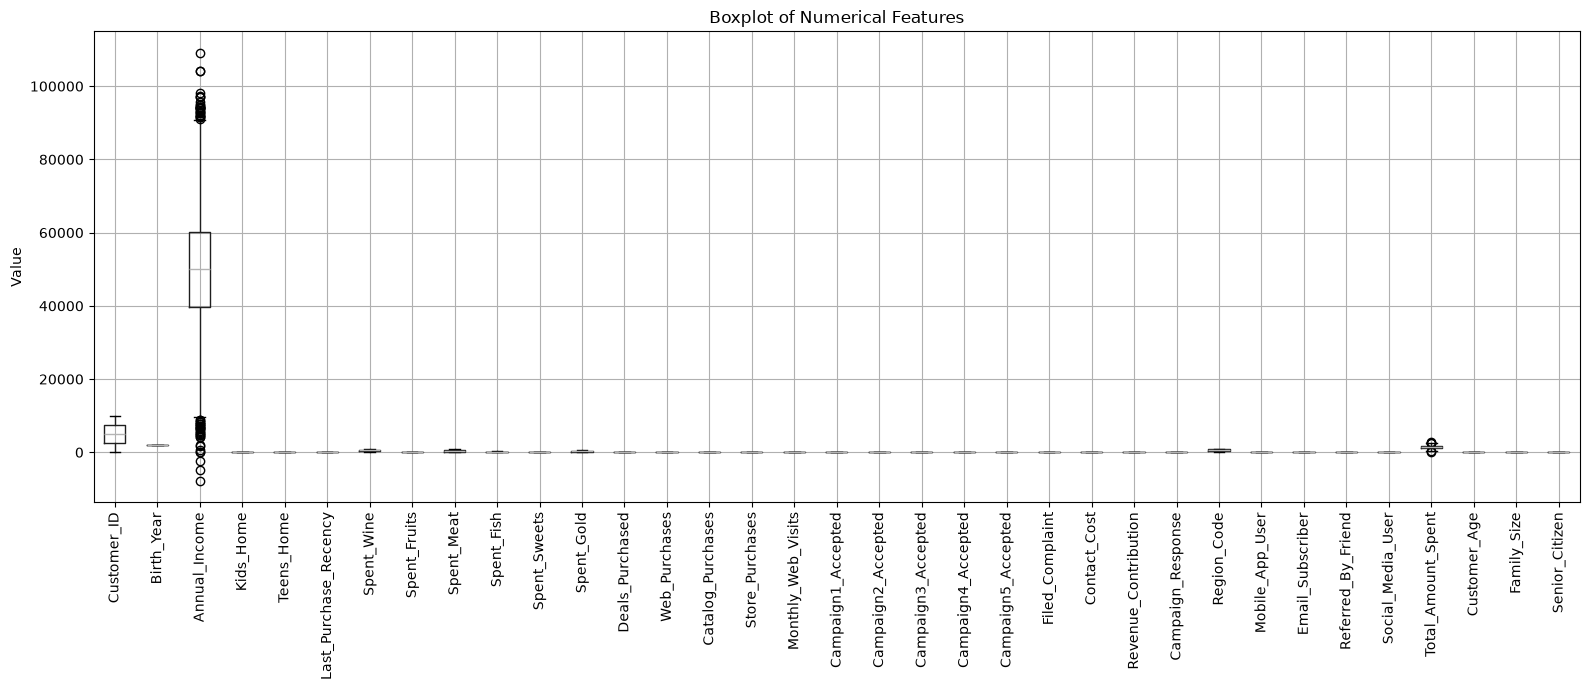

In [13]:
plt.figure(figsize=(16, 7))

df[numerical_columns].boxplot()

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

### What is the use?

The boxplot provides a visual way to identify unusually high or low observations.

We do not automatically delete every outlier because an unusual customer can still represent a real and meaningful customer segment.


## 15. Data Cleaning Summary

After the checks above, the dataset is retained without unnecessary deletion of valid customer records.

The cleaning decision is based on the actual checks rather than automatically removing rows.


In [14]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Cleaning checks completed.")

Missing values: 0
Duplicate rows: 0
Cleaning checks completed.


# 4️⃣ Remove Unnecessary Columns

Some columns are identifiers or redundant representations rather than useful clustering features.

- `Customer_ID` is an identifier and should not determine customer similarity.
- `Birth_Year` is redundant because `Customer_Age` is already available.
- `Customer_Since` is a date field and is not used directly in this numerical feature set.

No target/label is used because this is an unsupervised learning problem.


In [15]:
df_clean = df.copy()

columns_to_remove = [
    "Customer_ID",
    "Birth_Year",
    "Customer_Since"
]

df_clean = df_clean.drop(columns=columns_to_remove)

print("Removed columns:", columns_to_remove)
print("New shape:", df_clean.shape)

Removed columns: ['Customer_ID', 'Birth_Year', 'Customer_Since']
New shape: (10000, 39)


### What is the use?

Removing identifier and redundant columns prevents irrelevant information from influencing the distance calculations used by K-Means.


# 5️⃣ Feature Selection

For customer segmentation, the selected variables should represent customer behavior and characteristics that can help distinguish customer groups.

The selected features below focus mainly on income, spending, purchasing channels, engagement, campaign response, and customer characteristics.


In [16]:
selected_features = [
    "Annual_Income",
    "Kids_Home",
    "Teens_Home",
    "Last_Purchase_Recency",
    "Spent_Wine",
    "Spent_Fruits",
    "Spent_Meat",
    "Spent_Fish",
    "Spent_Sweets",
    "Spent_Gold",
    "Deals_Purchased",
    "Web_Purchases",
    "Catalog_Purchases",
    "Store_Purchases",
    "Monthly_Web_Visits",
    "Campaign1_Accepted",
    "Campaign2_Accepted",
    "Campaign3_Accepted",
    "Campaign4_Accepted",
    "Campaign5_Accepted",
    "Filed_Complaint",
    "Revenue_Contribution",
    "Campaign_Response",
    "Mobile_App_User",
    "Email_Subscriber",
    "Referred_By_Friend",
    "Social_Media_User",
    "Total_Amount_Spent",
    "Customer_Age",
    "Family_Size",
    "Senior_Citizen"
]

X = df_clean[selected_features].copy()

print("Number of selected features:", X.shape[1])
print("Selected feature matrix shape:", X.shape)

Number of selected features: 31
Selected feature matrix shape: (10000, 31)


### What is the use?

Feature selection reduces the analysis to variables that have a meaningful connection with customer segmentation.

The resulting `X` is the main feature matrix that will be prepared for K-Means.


# 6️⃣ Encoding

K-Means requires numerical input.

The selected feature list contains numerical variables, so there is no need to encode additional categorical columns for this particular clustering model.

The original categorical columns are not included in `X` because this analysis intentionally focuses on numerical customer behavior and characteristics.


In [17]:
selected_categorical = X.select_dtypes(include="object").columns.tolist()
selected_numerical = X.select_dtypes(include=np.number).columns.tolist()

print("Selected categorical columns:", selected_categorical)
print("Selected numerical columns:", len(selected_numerical))

if len(selected_categorical) == 0:
    print("\nNo categorical features were selected, so encoding is not required.")
else:
    print("\nCategorical features need encoding before clustering.")

Selected categorical columns: []
Selected numerical columns: 31

No categorical features were selected, so encoding is not required.


### What is the use?

This check prevents unnecessary encoding.

If categorical variables were selected, `OneHotEncoder` could be used. In this notebook, the selected clustering features are already numerical, so the feature matrix can proceed directly to scaling.


# 7️⃣ Feature Scaling

K-Means uses distances between observations.

Features with larger numerical ranges can dominate the distance calculation. Therefore, StandardScaler is applied before clustering.


In [18]:
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X.columns,
    index=X.index
)

print("Feature scaling completed.")
X_scaled.head()

Feature scaling completed.


,Annual_Income,Kids_Home,Teens_Home,Last_Purchase_Recency,Spent_Wine,Spent_Fruits,Spent_Meat,Spent_Fish,Spent_Sweets,Spent_Gold,...,Revenue_Contribution,Campaign_Response,Mobile_App_User,Email_Subscriber,Referred_By_Friend,Social_Media_User,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
0,-0.656292,0.003299,0.013131,0.632555,-0.201197,-0.544477,0.310679,0.763402,-0.720256,-1.430966,...,0.0,0.995012,1.012073,-1.023066,0.991635,0.998801,-0.447833,-0.402272,-0.300300,-0.817688
1,-1.476457,-1.218675,0.013131,1.697839,1.139460,-0.891080,-0.945763,-0.689695,1.197075,0.739250,...,0.0,-1.005013,1.012073,0.977454,0.991635,-1.001201,0.488123,-1.128434,-1.101102,-0.817688
2,0.996234,-1.218675,-1.214084,0.460735,1.379111,-1.653604,-0.373865,-0.516708,1.667692,0.307989,...,0.0,0.995012,-0.988071,-1.023066,-1.008436,0.998801,0.877696,0.156315,-1.101102,-0.817688
3,0.016934,1.225274,1.240346,0.529463,-1.288310,0.010086,0.834918,-0.516708,-0.040475,-0.109360,...,0.0,0.995012,-0.988071,0.977454,-1.008436,0.998801,-0.589942,0.938336,1.301302,1.222961
4,0.217157,0.003299,1.240346,-0.020361,-1.243159,-0.024574,-1.418012,0.740337,1.284226,0.238431,...,0.0,-1.005013,-0.988071,0.977454,0.991635,0.998801,-1.258832,-0.625706,1.301302,-0.817688


### What is the use?

`StandardScaler` transforms each feature so that its values are placed on a comparable scale.

This is especially important for features such as Annual Income and binary variables because their original ranges are very different.


## 16. Verify Feature Scaling

In [19]:
scaling_check = pd.DataFrame({
    "Mean": X_scaled.mean(),
    "Standard_Deviation": X_scaled.std()
})

scaling_check.round(2)

,Mean,Standard_Deviation
Annual_Income,0.0,1.0
Kids_Home,-0.0,1.0
Teens_Home,-0.0,1.0
Last_Purchase_Recency,-0.0,1.0
Spent_Wine,-0.0,1.0
Spent_Fruits,-0.0,1.0
Spent_Meat,-0.0,1.0
Spent_Fish,0.0,1.0
Spent_Sweets,-0.0,1.0
Spent_Gold,-0.0,1.0


### What is the use?

This confirms that the scaled features are centered close to zero and have a standard deviation close to one.


# 8️⃣ Final Data Validation

Before moving to PCA and K-Means, the final feature matrix is checked for shape, missing values, infinite values, and data type.


In [20]:
print("Final feature matrix shape:", X_scaled.shape)
print("Missing values:", X_scaled.isnull().sum().sum())
print("Infinite values:", np.isinf(X_scaled.to_numpy()).sum())
print("All features numerical:", X_scaled.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all())

Final feature matrix shape: (10000, 31)
Missing values: 0
Infinite values: 0
All features numerical: True


### What is the use?

This is the final quality check before machine learning.

The clustering model should receive clean numerical data without missing or infinite values.


# 9️⃣ PCA / Dimensionality Reduction

The original feature matrix contains many dimensions.

PCA is used to create two principal components so that the customer data and final clusters can be visualized in a two-dimensional graph.

PCA is used mainly for visualization here. K-Means itself will be trained using the complete scaled feature matrix.


In [21]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed.")
print("PCA shape:", X_pca.shape)

PCA completed.
PCA shape: (10000, 2)


## 17. Explained Variance

In [22]:
explained_variance = pca.explained_variance_ratio_

print("PC1 explained variance:", round(explained_variance[0], 4))
print("PC2 explained variance:", round(explained_variance[1], 4))
print("Total explained variance:", round(explained_variance.sum(), 4))

PC1 explained variance: 0.0666
PC2 explained variance: 0.064
Total explained variance: 0.1306


### What is the use?

Explained variance tells us how much of the information in the original feature space is represented by PC1 and PC2.


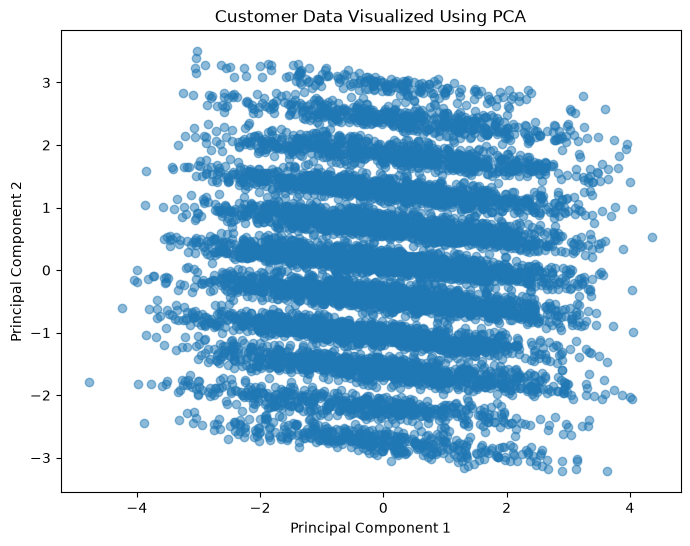

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Data Visualized Using PCA")

plt.show()

# 🔵 FINAL X FOR CLUSTERING

The final matrix used by K-Means is `X_scaled`.

PCA is kept separately as `X_pca` for visualization.

Therefore:

**K-Means input → `X_scaled`**

**PCA visualization → `X_pca`**


In [24]:
print("Final K-Means input:")
print("Rows:", X_scaled.shape[0])
print("Features:", X_scaled.shape[1])

Final K-Means input:
Rows: 10000
Features: 31


# 🟠 K-MEANS CLUSTERING

## 18. Understanding K-Means

K-Means divides the customers into a chosen number of clusters.

The algorithm repeatedly:

1. Starts with K cluster centers.
2. Assigns each customer to the nearest center.
3. Recalculates the cluster centers.
4. Repeats until the solution becomes stable.

The main question is: **What value of K should be used?**

For this, both the Elbow Method and Silhouette Score are checked.


## 19. Elbow Method

The Elbow Method uses K-Means inertia.

Inertia represents the total within-cluster squared distance. As K increases, inertia normally decreases.

We look for a point where the improvement starts becoming smaller.


In [25]:
inertia_values = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

print("Inertia values calculated.")

Inertia values calculated.


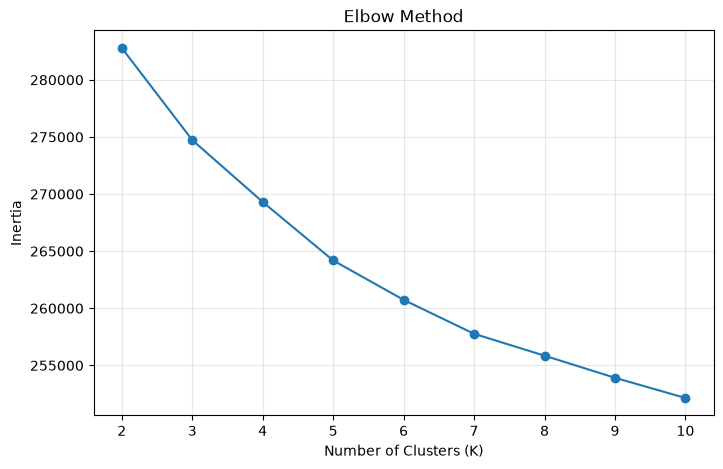

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.show()

### What is the use?

The elbow graph helps identify a practical number of clusters where increasing K gives diminishing improvement in inertia.


## 20. Silhouette Method

The Silhouette Score measures how well customers fit within their assigned clusters.

A higher score generally indicates better separation between clusters.


In [27]:
silhouette_values = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_values.append(score)

print("Silhouette scores calculated.")

Silhouette scores calculated.


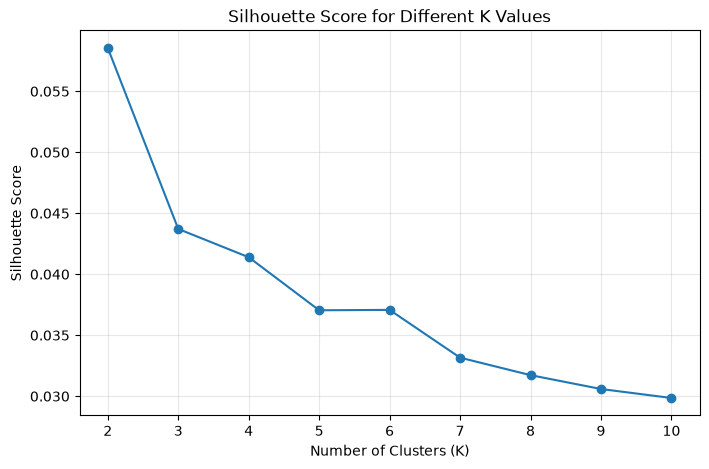

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.show()

### What is the use?

The Silhouette Score provides a numerical comparison of different K values.

The K with the highest score is a useful candidate, but the final choice should also consider the elbow plot and whether the resulting clusters are meaningful for the business problem.


## 21. Compare K Values

In [29]:
k_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette_Score": silhouette_values
})

k_results.round(4)

,K,Inertia,Silhouette_Score
0,2,282786.7194,0.0585
1,3,274728.2966,0.0437
2,4,269306.7177,0.0414
3,5,264188.4650,0.0370
4,6,260737.8601,0.0371
5,7,257765.6252,0.0332
6,8,255850.4115,0.0317
7,9,253914.8786,0.0306
8,10,252145.2733,0.0299


## 22. Select K Based on Silhouette Score

In [30]:
best_k = int(
    k_results.loc[
        k_results["Silhouette_Score"].idxmax(),
        "K"
    ]
)

print("K with the highest silhouette score:", best_k)

K with the highest silhouette score: 2


### Important note

The silhouette result gives a data-driven starting point for K selection.

The elbow graph should also be checked visually. If the elbow and silhouette results suggest different values, the final K should be chosen by considering both cluster quality and interpretability.


## 23. Train the Final K-Means Model

The K selected above is now used to train the final model.


In [31]:
final_k = best_k

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

print("Final K-Means model trained.")
print("Number of clusters:", final_k)

Final K-Means model trained.
Number of clusters: 2


## 24. Add Cluster Labels to the Dataset

In [32]:
df_clustered = df.copy()

df_clustered["Cluster"] = cluster_labels

df_clustered.head()

,Customer_ID,Birth_Year,Education_Level,Marital_Status,Annual_Income,Kids_Home,Teens_Home,Customer_Since,Last_Purchase_Recency,Spent_Wine,...,Email_Subscriber,Device_Type,Referred_By_Friend,Social_Media_User,Membership_Tier,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen,Cluster
0,1,1978,Graduation,Widow,40175.23,1,1,26-09-2010,68,440,...,0,Desktop,1,1,Silver,1265,47,2,0,0
1,2,1991,PhD,Widow,27979.68,0,1,03-11-2012,99,826,...,1,Desktop,1,0,Basic,1647,34,1,0,0
2,3,1968,PhD,Married,64747.68,0,0,31-10-2013,63,895,...,0,Desktop,0,1,Silver,1806,57,1,0,0
3,4,1954,Graduation,Widow,50185.85,2,2,30-04-2010,65,127,...,1,Mobile,0,1,Basic,1207,71,4,1,1
4,5,1982,Graduation,Married,53163.09,1,2,25-09-2015,49,140,...,1,Mobile,1,1,Basic,934,43,4,0,0


### What is the use?

Each customer now has a cluster label generated by K-Means.

The original customer information is retained so that the discovered clusters can be profiled and interpreted.


# 🔍 CLUSTER EVALUATION

The model is evaluated using the final Silhouette Score and cluster sizes.


## 25. Final Silhouette Score

In [33]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Final Silhouette Score:", round(final_silhouette, 4))

Final Silhouette Score: 0.0585


### What is the use?

This provides a single measure of how well-separated the final K-Means clusters are.


## 26. Cluster Sizes

In [34]:
cluster_sizes = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

Cluster
0    5993
1    4007
Name: count, dtype: int64

### What is the use?

Cluster size tells us how many customers belong to each discovered segment.


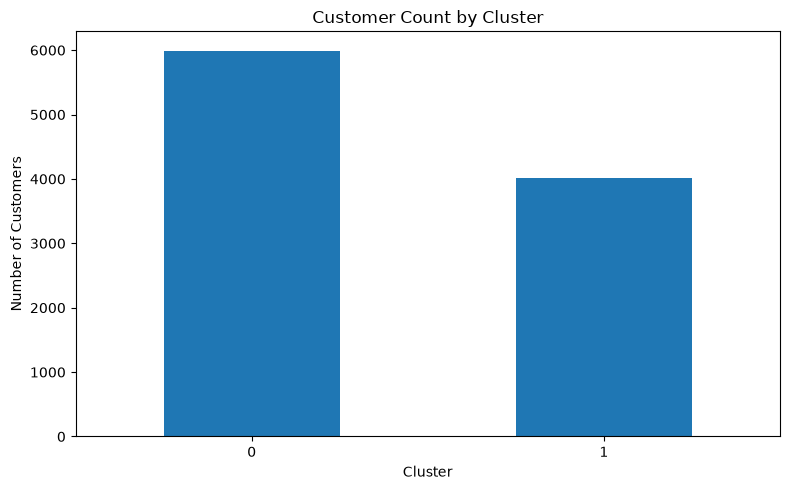

In [35]:
plt.figure(figsize=(8, 5))

cluster_sizes.plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Count by Cluster")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

# 📊 CLUSTER PROFILING

The next step is to understand what each cluster actually looks like.

Cluster profiling compares the average values of important customer features for each cluster.


## 27. Create Cluster Profile

In [36]:
profile_columns = [
    "Annual_Income",
    "Last_Purchase_Recency",
    "Spent_Wine",
    "Spent_Fruits",
    "Spent_Meat",
    "Spent_Fish",
    "Spent_Sweets",
    "Spent_Gold",
    "Deals_Purchased",
    "Web_Purchases",
    "Catalog_Purchases",
    "Store_Purchases",
    "Monthly_Web_Visits",
    "Campaign_Response",
    "Total_Amount_Spent",
    "Customer_Age"
]

cluster_profile = df_clustered.groupby("Cluster")[profile_columns].mean()

cluster_profile.round(2)

,Annual_Income,Last_Purchase_Recency,Spent_Wine,Spent_Fruits,Spent_Meat,Spent_Fish,Spent_Sweets,Spent_Gold,Deals_Purchased,Web_Purchases,Catalog_Purchases,Store_Purchases,Monthly_Web_Visits,Campaign_Response,Total_Amount_Spent,Customer_Age
Cluster,,,,,,,,,,,,,,,,
0,50239.03,49.83,503.51,49.71,400.89,148.17,99.20,251.52,4.52,4.50,4.46,4.54,9.49,0.49,1453.00,41.80
1,49477.90,49.24,489.58,49.71,401.89,149.75,99.51,249.53,4.51,4.46,4.46,4.48,9.44,0.51,1439.97,72.75


### What is the use?

This table tells us the average behavior of customers in each cluster.

For example, we can compare:

- Spending
- Income
- Purchase channels
- Website visits
- Campaign response
- Recency

and use those differences to describe the segments.


## 28. Add Number of Customers to the Profile

In [37]:
cluster_profile["Customer_Count"] = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_profile.round(2)

,Annual_Income,Last_Purchase_Recency,Spent_Wine,Spent_Fruits,Spent_Meat,Spent_Fish,Spent_Sweets,Spent_Gold,Deals_Purchased,Web_Purchases,Catalog_Purchases,Store_Purchases,Monthly_Web_Visits,Campaign_Response,Total_Amount_Spent,Customer_Age,Customer_Count
Cluster,,,,,,,,,,,,,,,,,
0,50239.03,49.83,503.51,49.71,400.89,148.17,99.20,251.52,4.52,4.50,4.46,4.54,9.49,0.49,1453.00,41.80,5993
1,49477.90,49.24,489.58,49.71,401.89,149.75,99.51,249.53,4.51,4.46,4.46,4.48,9.44,0.51,1439.97,72.75,4007


# 💡 BUSINESS INTERPRETATION

The following analysis prints the main values for each cluster. The final labels should be based on the actual numbers produced by the model rather than assigning names before seeing the results.


## 29. Display Important Business Metrics by Cluster

In [38]:
business_profile = cluster_profile[
    [
        "Customer_Count",
        "Annual_Income",
        "Total_Amount_Spent",
        "Last_Purchase_Recency",
        "Web_Purchases",
        "Catalog_Purchases",
        "Store_Purchases",
        "Monthly_Web_Visits",
        "Campaign_Response"
    ]
]

business_profile.round(2)

,Customer_Count,Annual_Income,Total_Amount_Spent,Last_Purchase_Recency,Web_Purchases,Catalog_Purchases,Store_Purchases,Monthly_Web_Visits,Campaign_Response
Cluster,,,,,,,,,
0,5993,50239.03,1453.00,49.83,4.50,4.46,4.54,9.49,0.49
1,4007,49477.90,1439.97,49.24,4.46,4.46,4.48,9.44,0.51


## 30. Compare Spending Across Clusters

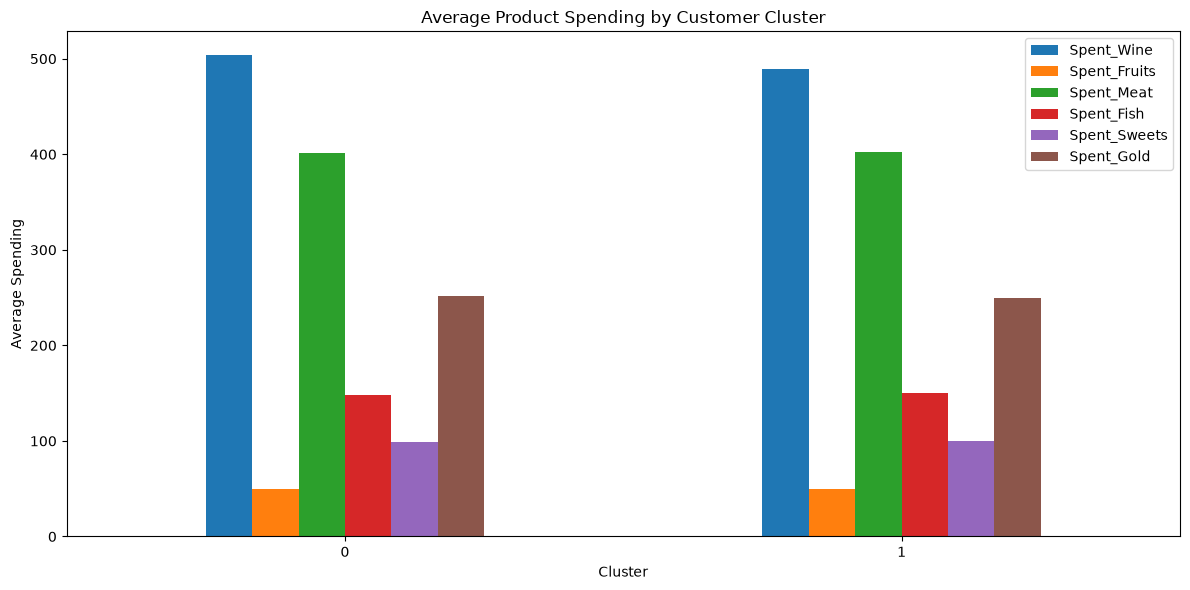

In [39]:
spending_columns = [
    "Spent_Wine",
    "Spent_Fruits",
    "Spent_Meat",
    "Spent_Fish",
    "Spent_Sweets",
    "Spent_Gold"
]

cluster_profile[spending_columns].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Product Spending by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spending")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### What is the use?

This graph compares product-category spending across the discovered customer groups.

It helps identify clusters with different product preferences.


## 31. Income vs Total Spending

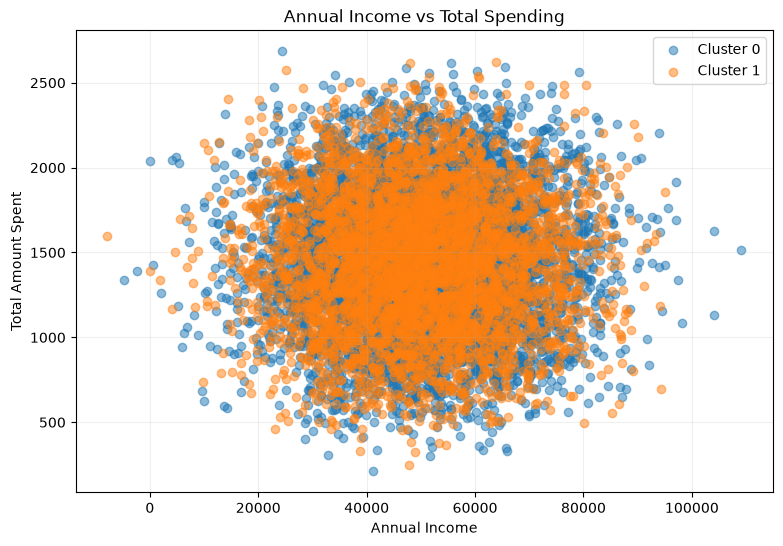

In [40]:
plt.figure(figsize=(9, 6))

for cluster in sorted(df_clustered["Cluster"].unique()):
    cluster_data = df_clustered[
        df_clustered["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["Annual_Income"],
        cluster_data["Total_Amount_Spent"],
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Annual Income")
plt.ylabel("Total Amount Spent")
plt.title("Annual Income vs Total Spending")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### What is the use?

This visualization shows the relationship between income and spending while distinguishing the discovered clusters.


# 📈 FINAL VISUALIZATION

## 32. K-Means Clusters in PCA Space

PCA is used here only to display the high-dimensional clusters in two dimensions.


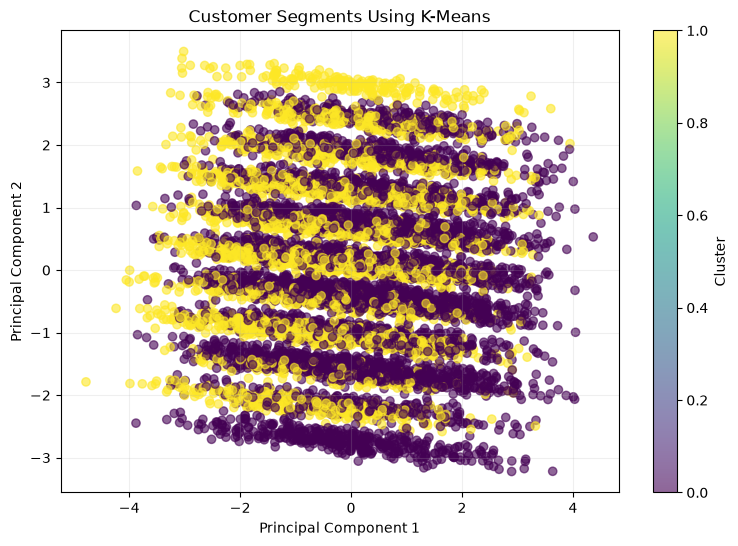

In [41]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments Using K-Means")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.2)
plt.show()

### What is the use?

This is the final visual representation of the customer segments.

Each point represents one customer, and the different cluster labels show the groups identified by K-Means.


## 33. Cluster Centroids

The final K-Means model has a centroid for every cluster.

Because the model was trained on scaled data, the centroid values are also in standardized units.


In [42]:
centroids = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=X.columns
)

centroids.round(2)

,Annual_Income,Kids_Home,Teens_Home,Last_Purchase_Recency,Spent_Wine,Spent_Fruits,Spent_Meat,Spent_Fish,Spent_Sweets,Spent_Gold,...,Revenue_Contribution,Campaign_Response,Mobile_App_User,Email_Subscriber,Referred_By_Friend,Social_Media_User,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
0,0.02,-0.0,-0.01,0.01,0.02,0.0,-0.0,-0.01,-0.0,0.01,...,0.0,-0.02,-0.01,-0.00,-0.01,0.00,0.01,-0.69,-0.0,-0.82
1,-0.03,0.0,0.01,-0.01,-0.03,-0.0,0.0,0.01,0.0,-0.01,...,0.0,0.02,0.02,0.01,0.01,-0.01,-0.02,1.04,0.0,1.22


### What is the use?

Centroids represent the central position of each cluster.

They can be used to understand which features are relatively high or low within each customer segment.


# 🏁 CONCLUSION

In this project, K-Means clustering was applied to customer data to discover groups of customers with similar characteristics and behavior.

The complete workflow included:

- Problem understanding
- Data understanding
- Data cleaning
- Removing unnecessary columns
- Feature selection
- Encoding check
- Feature scaling
- Final data validation
- PCA for dimensionality reduction and visualization
- K selection using Elbow and Silhouette methods
- K-Means clustering
- Cluster evaluation
- Cluster profiling
- Business interpretation
- Visualization

The resulting customer clusters can be used as a starting point for understanding different customer behaviors and developing segment-specific business strategies.

The important point is that the segments were **discovered from the data**, rather than being predefined.


## Final Model Summary

In [43]:
print("========== FINAL MODEL SUMMARY ==========")
print("Number of customers:", len(df_clustered))
print("Number of features used for clustering:", X_scaled.shape[1])
print("Selected K:", final_k)
print("Final Silhouette Score:", round(final_silhouette, 4))
print("Number of clusters created:", df_clustered["Cluster"].nunique())
print("=========================================")

========== FINAL MODEL SUMMARY ==========
Number of customers: 10000
Number of features used for clustering: 31
Selected K: 2
Final Silhouette Score: 0.0585
Number of clusters created: 2
